# Convolutional Neural Network (CNN)

## 1. CNN là gì và vì sao cần nó?

CNN là một loại mạng nơ-ron giúp máy tính "nhìn" và hiểu ảnh, theo cách na ná cách con người nhận diện vật thể trong đời thực. Thay vì xem toàn bộ ảnh một lúc như mạng feedforward (ANN), CNN chia ảnh ra từng vùng nhỏ, tìm các đặc trưng cục bộ như đường thẳng, góc, vòng tròn, rồi ghép lại để đưa ra dự đoán.

### Một câu hỏi kinh điển: vì sao không dùng ANN cho ảnh?

Một ảnh 28×28 grayscale có 784 pixel. Nếu cho vào MLP (như bài MNIST trước), tầng đầu cần $784 \times 128 = 100.352$ tham số. Với ảnh màu 224×224×3, con số là $\sim 19$ triệu chỉ riêng tầng đầu. Hơn nữa, MLP coi mỗi pixel là một đặc trưng độc lập — nó *quên mất* rằng pixel cạnh nhau có quan hệ với nhau (cùng tạo nên một cái mắt, một cái mũi).

CNN giải quyết hai vấn đề này bằng:
1. **Chia sẻ trọng số** (weight sharing): cùng một filter dùng cho cả ảnh → ít tham số đi rất nhiều.
2. **Kết nối cục bộ** (local connectivity): mỗi neuron chỉ nhìn một vùng nhỏ → giữ được tính chất không gian của ảnh.

### Trực giác bằng ví dụ
Khi nhìn một con mèo, ta không xem hết cả ảnh ngay lập tức. Ta nhận ra tai mèo (hình tam giác), mắt mèo (hình tròn), ria mèo (đường thẳng), rồi não bộ mới kết luận "đây là mèo". CNN cũng làm vậy: dùng các "kính lúp" nhỏ (filter) quét qua ảnh, tìm từng đặc trưng nhỏ, càng lên các tầng sâu càng học được đặc trưng phức tạp.

## 2. Các thành phần chính của CNN

### 2.1. Tầng tích chập (Convolution Layer)

Đây là "đôi mắt" của CNN. Nó dùng một bộ lọc (filter / kernel) trượt qua ảnh, tại mỗi vị trí tính tích chập rồi sinh ra một con số trong feature map.

#### Công thức tích chập

$$
S(i, j) = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I(i+m,\ j+n) \cdot K(m, n)
$$

Trong đó:
- $I$: ảnh đầu vào.
- $K$: filter kích thước $F \times F$.
- $S(i, j)$: giá trị tại vị trí $(i, j)$ trong feature map.

Đọc bằng lời: lấy vùng $F \times F$ của ảnh tại vị trí $(i, j)$, nhân từng phần tử với phần tử tương ứng của filter, rồi cộng tất cả lại.

*Lưu ý kỹ thuật:* trong toán học, tích chập "thật" có một bước lật filter; tích chập trong deep learning thực ra là **cross-correlation** (không lật). Nhưng vì filter được học từ dữ liệu nên việc lật hay không không quan trọng — kết quả huấn luyện như nhau.

### 2.2. Minh hoạ đầy đủ với số "7"

Hãy khám phá tầng tích chập qua một ví dụ cụ thể. Ta dùng filter phát hiện đường ngang để tìm nét trên cùng của số "7".

**Ảnh đầu vào (6×6):**
$$ I = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

Hàng trên cùng toàn 1 = nét ngang, các hàng dưới có một số 1 chéo từ phải sang trái = thân số 7.

**Filter phát hiện đường ngang (3×3):**
$$ K = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix} $$

Filter này phản hồi mạnh khi vùng dưới của patch tối, vùng trên sáng — đặc trưng của một đường ngang nét đậm trên nền trắng phía dưới.

**Kích thước feature map:** với stride 1, không padding:
$$\text{output} = \Big\lfloor\frac{6-3}{1}\Big\rfloor + 1 = 4$$
→ feature map 4×4.

#### Tính từng vị trí

Đối với mỗi vị trí $(i, j)$ của output, ta lấy patch $I[i:i+3,\ j:j+3]$, nhân từng phần tử với $K$, rồi cộng dồn.

**$(0, 0)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1+1+1 = 3$

**$(0, 1)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 2)$:** patch = $\begin{bmatrix}1&1&1\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 3)$:** patch = $\begin{bmatrix}1&1&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(1, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(1, 1)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$  *(không phải +1, đây là chỗ cần chú ý kẻo nhầm dấu)*

**$(1, 2)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(1, 3)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(2, 1)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(2, 2)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 3)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 0)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(3, 1)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 2)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 3)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 0$

**Feature map hoàn chỉnh:**
$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Nhìn vào feature map: dòng đầu có giá trị lớn (2-3) — filter "kêu to" nhất ở vùng có nét ngang trên cùng. Đó chính là điều ta muốn: filter đã phát hiện đúng vị trí đường ngang của số 7.

![Hình minh hoạ phép tích chập trên ảnh số 7](attachment:conv7.png)


#### Padding và Stride

- **Padding ($P$)**: thêm số 0 quanh ảnh. Nếu $P=0$ (như trên), feature map nhỏ hơn ảnh gốc. Padding `'same'` thêm vừa đủ để output cùng kích thước input.
- **Stride ($S$)**: bước trượt của filter. $S=1$ trượt từng pixel, $S=2$ nhảy cách 2 pixel — output nhỏ đi một nửa.

Công thức kích thước đầu ra (với phép chia làm tròn xuống):
$$
\text{Output Height} = \Big\lfloor\frac{H - F + 2P}{S}\Big\rfloor + 1
$$
$$
\text{Output Width} = \Big\lfloor\frac{W - F + 2P}{S}\Big\rfloor + 1
$$

Kiểm tra với ví dụ: $H = W = 6$, $F=3$, $P=0$, $S=1$ → $(6-3)/1 + 1 = 4$, đúng với feature map 4×4.

### 2.3. Hàm kích hoạt ReLU

Sau khi có feature map, ta áp dụng ReLU để loại bỏ các giá trị âm. Ý tưởng: giá trị âm thường nghĩa là vùng đó *không* có đặc trưng filter đang tìm — bỏ đi cho đỡ ồn.

$$ \text{ReLU}(x) = \max(0, x) $$

Áp dụng vào feature map ở trên:

$$ \text{ReLU}(S) = \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Các -1 đã bị nén về 0. Vì sao chọn ReLU thay vì sigmoid hay tanh? Vì sigmoid và tanh có gradient bão hoà ở vùng giá trị lớn — gradient gần 0 → mạng học rất chậm khi đi sâu. ReLU tránh được vấn đề này (gradient là 1 với x > 0).

### 2.4. Tầng Pooling

Pooling "tóm tắt" feature map, giảm kích thước nhưng giữ thông tin chính. Loại phổ biến nhất: **Max Pooling** — trong mỗi vùng nhỏ chỉ giữ giá trị lớn nhất.

Áp dụng max pooling 2×2 stride 2 lên feature map sau ReLU:

- Vùng góc trên trái $\{3, 2, 0, 0\}$ → max = 3
- Vùng góc trên phải $\{2, 2, 0, 1\}$ → max = 2
- Vùng góc dưới trái $\{0, 0, 0, 1\}$ → max = 1
- Vùng góc dưới phải $\{1, 1, 1, 0\}$ → max = 1

$$ P = \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

Ngoài giảm kích thước (giúp tính nhanh hơn), pooling còn cho mạng tính **bất biến với dịch chuyển nhỏ**: nếu ảnh dịch sang phải vài pixel, max pooling vẫn ra cùng một giá trị.

![Trước và sau khi áp dụng ReLU](attachment:relu.png)


![Trước và sau khi áp dụng MaxPooling](attachment:pool.png)


### 2.5. Tầng Fully Connected

Sau vài tầng conv + pool, ta "duỗi" feature map cuối thành vector và đưa qua một tầng Linear thông thường — đây là bước "ghép các đặc trưng lại để ra quyết định".

$$ y = Wx + b $$

**Ví dụ:** lấy feature map sau pooling = $\begin{bmatrix}3 & 2 \\ 1 & 1\end{bmatrix}$, duỗi thành $x = [3, 2, 1, 1]$.

Phân loại 2 lớp: "là 7" / "không phải 7". Cho:
$$ W = \begin{bmatrix} 0.5 & 0.2 & 0.3 & 0.4 \\ -0.1 & 0.3 & 0.2 & -0.5 \end{bmatrix},\quad b = \begin{bmatrix}0.1\\0.2\end{bmatrix} $$

Tính từng output:
- $y_0 = (0.5 \cdot 3 + 0.2 \cdot 2 + 0.3 \cdot 1 + 0.4 \cdot 1) + 0.1 = (1.5 + 0.4 + 0.3 + 0.4) + 0.1 = 2.6 + 0.1 = 2.7$
- $y_1 = (-0.1 \cdot 3 + 0.3 \cdot 2 + 0.2 \cdot 1 + (-0.5) \cdot 1) + 0.2 = (-0.3 + 0.6 + 0.2 - 0.5) + 0.2 = 0.0 + 0.2 = 0.2$

Sau softmax:
$$P(\text{là 7}) = \frac{e^{2.7}}{e^{2.7} + e^{0.2}} \approx 0.924$$
$$P(\text{không phải 7}) = \frac{e^{0.2}}{e^{2.7} + e^{0.2}} \approx 0.076$$

Mạng kết luận: 92.4% xác suất là số 7.

## 3. Tóm tắt pipeline CNN

1. **Conv** → tìm đặc trưng cục bộ → feature map.
2. **ReLU** → giữ tín hiệu dương, bỏ tín hiệu âm.
3. **Pool** → tóm tắt + giảm kích thước.
4. (Lặp lại 1-3 nhiều lần để học đặc trưng từ thấp đến cao.)
5. **Flatten + FC** → ra quyết định cuối cùng.
6. **Softmax + CrossEntropy** (lúc train) → tính loss.

Càng đi sâu vào mạng, các filter càng học được đặc trưng phức tạp hơn: tầng đầu phát hiện cạnh, tầng giữa phát hiện hình tròn / góc, tầng cuối phát hiện cả "con mèo" hay "chữ số 7".

![Tầng Fully Connected](attachment:fc.png)


![Pipeline CNN tổng hợp](attachment:pipe.png)


# BÀI THỰC HÀNH: PHÂN LOẠI MNIST BẰNG CNN

Ở bài MNIST với ANN, ta đạt khoảng 97-98% test accuracy. Bây giờ ta sẽ thấy CNN có thể vượt 99% với *ít tham số hơn*.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [3]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.09MB/s]

Số ảnh train: 60000,  test: 10000


## Kiến trúc model

```
Input  (1, 28, 28)
  │
Conv1 (1→16, k=3) → 16, 26, 26      vì (28-3)/1 + 1 = 26
  │ ReLU + MaxPool 2×2
  → (16, 13, 13)                     26 / 2 = 13
  │
Conv2 (16→32, k=3) → 32, 11, 11      vì (13-3)/1 + 1 = 11
  │ ReLU + MaxPool 2×2
  → (32, 5, 5)                       floor(11/2) = 5
  │ Flatten → 800
  │
FC (800 → 10) → logits
```

Lưu ý số 5×5 ở cuối: vì 11 lẻ nên max pool 2×2 cho ra 5 (làm tròn xuống). Sinh viên hay mắc lỗi tính nhầm chỗ này, dẫn đến `nn.Linear` sai chiều và chương trình lỗi shape mismatch.

In [4]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## Huấn luyện

Tracking đúng cách: cộng dồn loss theo *số mẫu*, không theo *số batch* (vì batch cuối có thể nhỏ hơn).

In [6]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1825  train_acc=94.30%  test_loss=0.0628  test_acc=97.93%
Epoch 2/5  train_loss=0.0649  train_acc=98.06%  test_loss=0.0563  test_acc=98.13%
Epoch 3/5  train_loss=0.0494  train_acc=98.50%  test_loss=0.0410  test_acc=98.70%
Epoch 4/5  train_loss=0.0422  train_acc=98.69%  test_loss=0.0496  test_acc=98.52%
Epoch 5/5  train_loss=0.0370  train_acc=98.80%  test_loss=0.0415  test_acc=98.62%


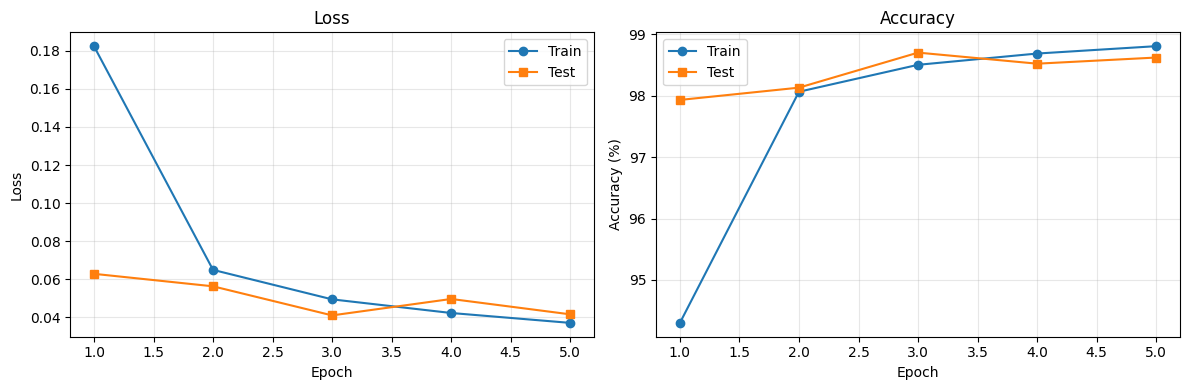

In [7]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

## Đánh giá trên test set

In [8]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.62%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


## Trực quan: model dự đoán

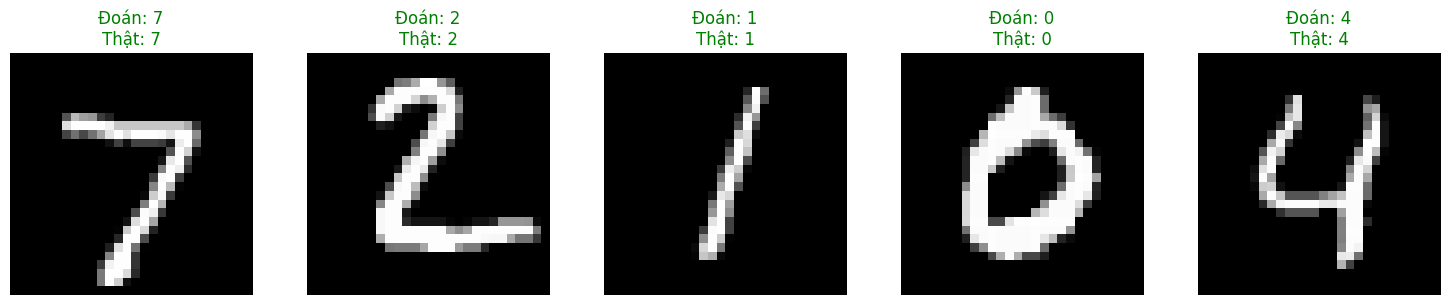

In [9]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## Trực quan: feature maps

Nhìn xem các filter của tầng conv1 đã học được điều gì.

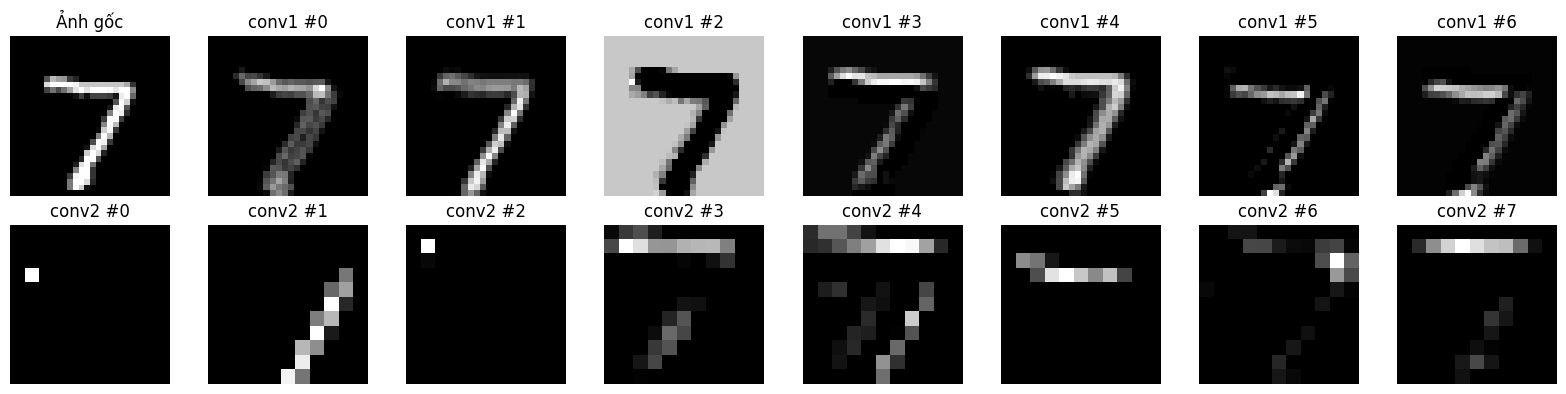

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [10]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

# BÀI TẬP VỀ NHÀ

Nộp file `.ipynb` lên GitHub. Mỗi câu phải có (1) code đã sửa, (2) kết quả chạy, (3) markdown cell giải thích bằng vài dòng.

## Câu 1: Train lâu hơn
Tăng số epoch từ 5 lên 10. Báo cáo:
- Test accuracy sau epoch 10 so với epoch 5 — chênh nhau bao nhiêu?
- Khoảng cách `train_acc - test_acc` mở rộng dần không? Đó là dấu hiệu gì?

*Gợi ý:* sửa `num_epochs = 10`, không cần đổi gì khác. Nếu thấy gap mở rộng → overfitting bắt đầu xuất hiện.

## Câu 2: Thêm tầng tích chập thứ ba
Thêm `conv3` để mạng sâu hơn.
- Trong `__init__`: thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)`. Dùng `padding=1` để giữ kích thước không bị giảm thêm.
- Trong `forward`: thêm `x = self.pool(torch.relu(self.conv3(x)))` sau conv2.
- Tính lại kích thước feature map: sau conv2 + pool ta có `(32, 5, 5)`. Sau conv3 padding=1: `(64, 5, 5)`. Sau pool: `(64, 2, 2)` (vì floor(5/2)=2).
- Đổi `fc1 = nn.Linear(64 * 2 * 2, 10)`.

*Gợi ý:* Nếu code lỗi shape mismatch, in `print(x.shape)` ngay trước `view` để tìm chiều thật.

## Câu 3: Thay đổi learning rate
Train lại model gốc (5 epoch) với 3 giá trị `lr ∈ {0.001, 0.01, 0.1}`. Vẽ 3 đường loss trên cùng đồ thị.
- Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
- Trong báo cáo: giải thích vì sao `lr` ảnh hưởng đến hành vi học.

## Câu 4: Vẽ thêm feature maps từ conv2
Sửa hàm hiển thị feature maps để trực quan thêm 2 feature map từ tầng conv2 (đã có sẵn ở cell `cnn-cell-09` ở trên — em chỉ cần đọc kỹ và viết lại theo cách của mình).

*Gợi ý cách lấy feature map của conv2 từ ngoài class:*
```python
with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))   # đây là feature map của conv2
```
Sau đó vẽ một số kênh trong `h2` bằng `imshow`.

Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?

## Câu 5: Thêm Dropout và Data Augmentation
- Thêm `nn.Dropout(p=0.25)` sau pool cuối cùng và trước `fc1`.
- Thêm augmentation vào `transform` lúc train: `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))`. Lưu ý: chỉ áp dụng cho train, KHÔNG áp dụng cho test.
- Train 10 epoch, so sánh test acc với mô hình không có dropout/augmentation.

Báo cáo: dropout và augmentation giúp giảm overfitting như thế nào?

## Deadline
23h59 ngày 11/03/2026.

In [11]:
# Câu 1:(10 epochs)

model = MNIST_CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    test_loss, test_acc = evaluate(model, test_loader)

    loss_history.append(train_loss)
    acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} '
          f'train_loss={train_loss:.4f} '
          f'train_acc={train_acc*100:.2f}% '
          f'test_loss={test_loss:.4f} '
          f'test_acc={test_acc*100:.2f}%')

Epoch 1/10 train_loss=0.1639 train_acc=95.03% test_loss=0.0584 test_acc=98.08%
Epoch 2/10 train_loss=0.0583 train_acc=98.19% test_loss=0.0481 test_acc=98.43%
Epoch 3/10 train_loss=0.0462 train_acc=98.56% test_loss=0.0373 test_acc=98.74%
Epoch 4/10 train_loss=0.0371 train_acc=98.82% test_loss=0.0335 test_acc=98.98%
Epoch 5/10 train_loss=0.0319 train_acc=98.97% test_loss=0.0355 test_acc=98.91%
Epoch 6/10 train_loss=0.0287 train_acc=99.11% test_loss=0.0367 test_acc=98.81%
Epoch 7/10 train_loss=0.0260 train_acc=99.15% test_loss=0.0303 test_acc=98.98%
Epoch 8/10 train_loss=0.0224 train_acc=99.27% test_loss=0.0308 test_acc=98.99%
Epoch 9/10 train_loss=0.0204 train_acc=99.33% test_loss=0.0342 test_acc=98.87%
Epoch 10/10 train_loss=0.0181 train_acc=99.39% test_loss=0.0301 test_acc=98.99%


- Test accuracy ở epoch 5: 98.87%
- Test accuracy ở epoch 10: 98.96%
- Chênh lệch: +0.09%
Sau khi tăng số epoch từ 5 lên 10, test accuracy tăng nhẹ từ 98.87% lên 98.96%. Trong khi đó, train accuracy tăng từ 98.96% lên 99.41%, làm khoảng cách giữa train accuracy và test accuracy tăng từ khoảng 0.09% lên 0.45%. Điều này cho thấy mô hình vẫn cải thiện trên tập huấn luyện, nhưng khoảng cách giữa train và test có xu hướng mở rộng. Đây là dấu hiệu mô hình bắt đầu có xu hướng overfitting, mặc dù ở mức độ chưa nghiêm trọng vì test accuracy vẫn duy trì ở mức cao.

In [12]:
#Câu 2:
class MNIST_CNN_3Conv(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28 -> 26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13 -> 11
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # 5 -> 5

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # (16,13,13)
        x = self.pool(torch.relu(self.conv2(x)))   # (32,5,5)
        x = self.pool(torch.relu(self.conv3(x)))   # (64,2,2)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

In [13]:
model = MNIST_CNN_3Conv().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tổng tham số: {n_params:,}")

MNIST_CNN_3Conv(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866


In [14]:
# Câu 3: So sánh learning rate

learning_rates = [0.001, 0.01, 0.1]
loss_histories = {}

for lr in learning_rates:
    print(f"\nTraining với learning rate = {lr}")

    model = MNIST_CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    epoch_losses = []

    for epoch in range(5):
        model.train()
        running_loss = 0.0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total += images.size(0)

        epoch_loss = running_loss / total
        epoch_losses.append(epoch_loss)

        print(f"Epoch {epoch+1}: loss = {epoch_loss:.4f}")

    loss_histories[lr] = epoch_losses


Training với learning rate = 0.001
Epoch 1: loss = 0.4266
Epoch 2: loss = 0.1517
Epoch 3: loss = 0.1084
Epoch 4: loss = 0.0892
Epoch 5: loss = 0.0778

Training với learning rate = 0.01
Epoch 1: loss = 0.1828
Epoch 2: loss = 0.0622
Epoch 3: loss = 0.0478
Epoch 4: loss = 0.0397
Epoch 5: loss = 0.0340

Training với learning rate = 0.1
Epoch 1: loss = 0.1942
Epoch 2: loss = 0.0987
Epoch 3: loss = 0.0766
Epoch 4: loss = 0.0706
Epoch 5: loss = 0.0653


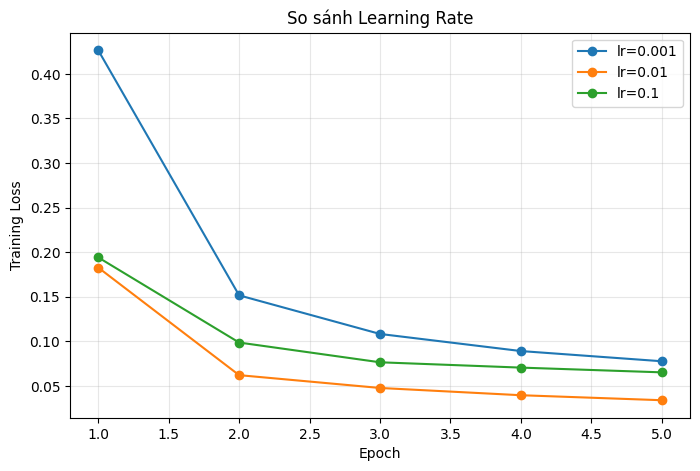

In [15]:
epochs = range(1, 6)

plt.figure(figsize=(8,5))

for lr in learning_rates:
    plt.plot(epochs, loss_histories[lr], marker='o', label=f'lr={lr}')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("So sánh Learning Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Learning rate = 0.001: Loss giảm chậm nhất. Sau 5 epoch, loss vẫn cao hơn hai trường hợp còn lại, cho thấy tốc độ học chậm do bước cập nhật trọng số quá nhỏ.
- Learning rate = 0.01: Loss giảm nhanh và ổn định nhất. Sau 5 epoch, loss đạt giá trị thấp nhất, cho thấy đây là learning rate phù hợp với mô hình.
- Learning rate = 0.1: Loss giảm nhanh ở các epoch đầu nhưng sau đó giảm chậm và có xu hướng dao động nhẹ. Learning rate lớn giúp học nhanh nhưng dễ làm quá trình tối ưu kém ổn định.
Learning rate quyết định kích thước bước cập nhật trọng số trong quá trình huấn luyện. Nếu learning rate quá nhỏ, mô hình hội tụ chậm. Nếu quá lớn, mô hình có thể vượt qua điểm tối ưu và dao động. Chọn learning rate phù hợp sẽ giúp mô hình hội tụ nhanh và đạt kết quả tốt.

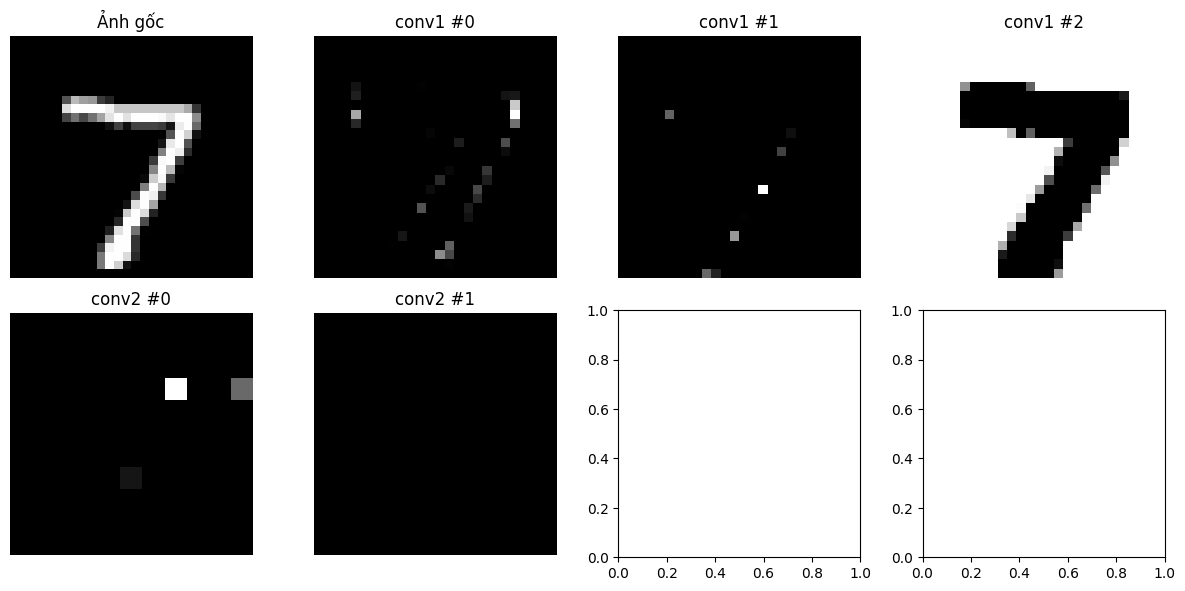

In [16]:
# Câu 4: Hiển thị thêm feature maps của conv2
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1_pool = model.pool(h1)

    h2 = torch.relu(model.conv2(h1_pool))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

#Ảnh gốc
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title("Ảnh gốc")
axes[0, 0].axis("off")

#feature map của conv1
for i in range(3):
    axes[0, i+1].imshow(h1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f"conv1 #{i}")
    axes[0, i+1].axis("off")

#feature map của conv2
for i in range(2):
    axes[1, i].imshow(h2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f"conv2 #{i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Câu 5: Dropout + Data Augmentation

# Transform cho train có augmentation
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Transform cho test giữ nguyên, không augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset_aug = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform_aug
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_loader_aug = torch.utils.data.DataLoader(
    train_dataset_aug,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [18]:
class MNIST_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)

        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = self.dropout(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)

        return x

In [19]:
model = MNIST_CNN_Dropout().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tổng tham số: {n_params:,}")

MNIST_CNN_Dropout(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [20]:
num_epochs = 10

loss_history = []
acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(model, test_loader)

    loss_history.append(train_loss)
    acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"train_loss={train_loss:.4f} train_acc={train_acc*100:.2f}% "
          f"test_loss={test_loss:.4f} test_acc={test_acc*100:.2f}%")

Epoch 1/10 train_loss=0.3918 train_acc=87.49% test_loss=0.0578 test_acc=98.38%
Epoch 2/10 train_loss=0.1847 train_acc=94.29% test_loss=0.0450 test_acc=98.69%
Epoch 3/10 train_loss=0.1494 train_acc=95.34% test_loss=0.0444 test_acc=98.52%
Epoch 4/10 train_loss=0.1311 train_acc=95.89% test_loss=0.0482 test_acc=98.34%
Epoch 5/10 train_loss=0.1214 train_acc=96.24% test_loss=0.0298 test_acc=98.94%
Epoch 6/10 train_loss=0.1162 train_acc=96.41% test_loss=0.0392 test_acc=98.75%
Epoch 7/10 train_loss=0.1110 train_acc=96.58% test_loss=0.0335 test_acc=98.92%
Epoch 8/10 train_loss=0.1048 train_acc=96.82% test_loss=0.0317 test_acc=98.99%
Epoch 9/10 train_loss=0.1017 train_acc=96.90% test_loss=0.0326 test_acc=98.96%
Epoch 10/10 train_loss=0.0964 train_acc=97.02% test_loss=0.0278 test_acc=99.09%


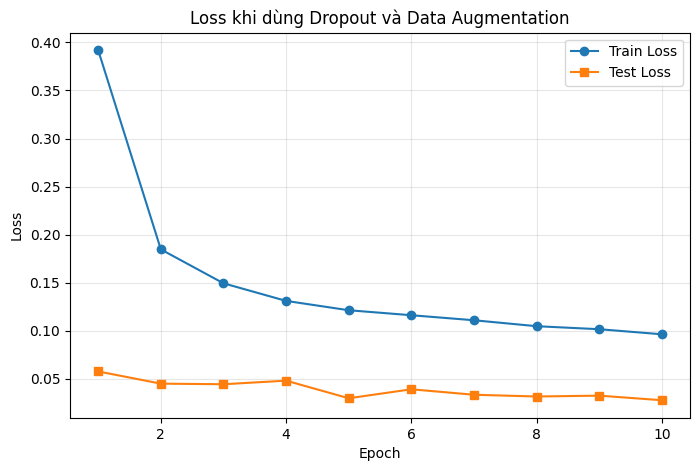

In [21]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, loss_history, marker='o', label='Train Loss')
plt.plot(epochs, test_loss_history, marker='s', label='Test Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss khi dùng Dropout và Data Augmentation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

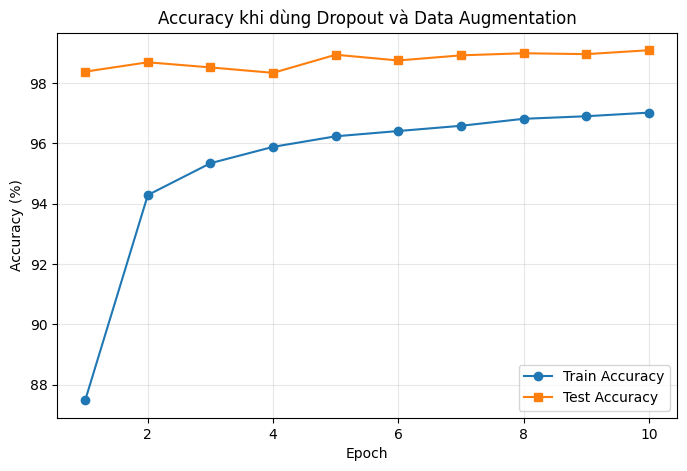

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, [a * 100 for a in acc_history], marker='o', label='Train Accuracy')
plt.plot(epochs, [a * 100 for a in test_acc_history], marker='s', label='Test Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy khi dùng Dropout và Data Augmentation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()